<a href="https://colab.research.google.com/github/cherylshah15/apd-git-experiment/blob/main/I065_Lab9_EC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PSO

Step 1: Import Required Libraries

In [ ]:
import numpy as np
import time

Step 2: Define the Fitness Function

In [ ]:
def fitness_function(x):
    x1 = x[0]
    x2 = x[1]
    return 100*(x1-x2)**2 + (1-x1)**2

Step 3: Initialize PSO Parameters

In [ ]:
num_particles = 30
dimensions = 2
max_iterations = 50

w = 0.7
c1 = 1.5
c2 = 1.5

lower_bound = -5
upper_bound = 5

Step 4: Initialize Particles and Velocities

In [ ]:
positions = np.random.uniform(lower_bound, upper_bound, (num_particles, dimensions))
velocities = np.random.uniform(-1, 1, (num_particles, dimensions))

Step 5: Initialize Personal and Global Best

In [ ]:
pbest_positions = positions.copy()
pbest_values = np.array([fitness_function(p) for p in positions])

gbest_index = np.argmin(pbest_values)
gbest_position = pbest_positions[gbest_index]
gbest_value = pbest_values[gbest_index]

Step 6: PSO Iterations

In [ ]:
start_time = time.time()

pso_history = [] # Initialize or clear pso_history before the loop

for iteration in range(max_iterations):

    for i in range(num_particles):

        r1 = np.random.rand(dimensions)
        r2 = np.random.rand(dimensions)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - positions[i])
            + c2 * r2 * (gbest_position - positions[i])
        )

        positions[i] = positions[i] + velocities[i]
        positions[i] = np.clip(positions[i], lower_bound, upper_bound)

        fitness = fitness_function(positions[i])

        if fitness < pbest_values[i]:
            pbest_positions[i] = positions[i]
            pbest_values[i] = fitness

    gbest_index = np.argmin(pbest_values)
    gbest_position = pbest_positions[gbest_index]
    gbest_value = pbest_values[gbest_index]
    pso_history.append(gbest_value) # Record the best fitness of the current iteration

end_time = time.time()

Step 7: Results

In [ ]:
print("PSO Result")
print("Optimal solution (x1, x2):", gbest_position)
print("Minimum value:", gbest_value)
print("Execution time:", end_time - start_time, "seconds")

PSO Result
Optimal solution (x1, x2): [1.00000089 1.00000086]
Minimum value: 8.631607188365714e-13
Execution time: 0.03440666198730469 seconds


Algorithm Comparison

In [ ]:
import numpy as np
import time

# fitness function
def fitness_function(x):
    x1, x2 = x
    return 100*(x1-x2)**2 + (1-x1)**2

# parameters
pop_size = 30
dimensions = 2
generations = 100

lower_bound = -5
upper_bound = 5

F = 0.8
CR = 0.9

# initialize population
population = np.random.uniform(lower_bound, upper_bound, (pop_size, dimensions))

de_history = [] # Initialize or clear de_history before the loop

start = time.time()

for g in range(generations):

    for i in range(pop_size):

        idxs = list(range(pop_size))
        idxs.remove(i)

        a, b, c = population[np.random.choice(idxs, 3, replace=False)]

        # mutation
        mutant = np.clip(a + F*(b-c), lower_bound, upper_bound)

        # crossover
        cross = np.random.rand(dimensions) < CR
        trial = np.where(cross, mutant, population[i])

        # selection
        if fitness_function(trial) < fitness_function(population[i]):
            population[i] = trial

    # Record the best fitness of the current generation
    de_history.append(fitness_function(min(population, key=fitness_function))) # Appending fitness value

best = min(population, key=fitness_function)

end = time.time()

print("Differential Evolution Result")
print("Optimal solution:", best)
print("Minimum value:", fitness_function(best))
print("Execution time:", end - start, "seconds")

Differential Evolution Result
Optimal solution: [0.99999997 0.99999998]
Minimum value: 3.369017350471369e-15
Execution time: 0.16686677932739258 seconds


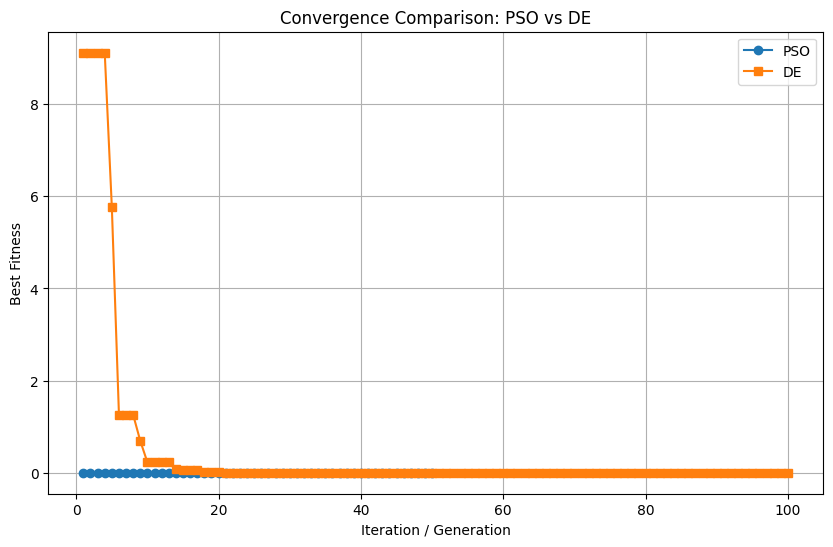

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(range(1,max_iterations+1), pso_history, label="PSO", marker='o')
plt.plot(range(1,generations+1), de_history, label="DE", marker='s')
plt.xlabel("Iteration / Generation")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison: PSO vs DE")
plt.legend()
plt.grid(True)
plt.show()

Gradio

In [ ]:
def run_experiment(particles, iterations):

    pso_best, pso_history = run_pso(particles, iterations)
    de_best, de_history = run_de(particles, iterations)

    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(pso_history, label="PSO")
    plt.plot(de_history, label="DE")
    plt.xlabel("Iterations")
    plt.ylabel("Best Fitness")
    plt.title("PSO vs DE Comparison")
    plt.legend()

fig, ax = plt.subplots()
ax.plot(pso_history, label="PSO")
ax.plot(de_history, label="DE")
ax.set_xlabel("Iterations")
ax.set_ylabel("Best Fitness")
ax.set_title("PSO vs DE Comparison")
ax.legend()
    result = f"""
PSO Best Value: {pso_best}
DE Best Value: {de_best}
"""

    return result, fig

    interface = gr.Interface(
    fn=run_experiment,
    inputs=[
        gr.Slider(10,100,value=30,label="Particles / Population"),
        gr.Slider(10,200,value=50,label="Iterations")
    ],
    outputs=[
        gr.Textbox(label="Results"),
        gr.Plot(label="PSO vs DE Comparison Graph")
    ],
    title="PSO vs Differential Evolution Optimization",
    description="Compare Particle Swarm Optimization and Differential Evolution"
)

interface.launch(debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f3b44d8c137494b2b3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^